# 纯度影响趋势分析

In [8]:
import os,gzip,pickle
from utils.keys import Cols
import numpy as np
import pandas as pd
import math
import matplotlib
import matplotlib.pyplot as plt

# 设置字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei, Times New Roman'
# 全局设置字号
plt.rcParams.update({
    'font.size': 16,  # 基础字号
    'axes.titlesize': 20,  # 标题字号
    'axes.labelsize': 20,  # 坐标轴标签字号
    'xtick.labelsize': 20,  # x轴刻度标签字号
    'ytick.labelsize': 20,  # y轴刻度标签字号
    'legend.fontsize': 16  # 图例字号
})
# 解决负号显示问题
matplotlib.rcParams['axes.unicode_minus'] = False

In [9]:
with gzip.open(
    r'D:\Devs\Single_Stack_MLJ\data\processed\Test data Hyzenis\2.03-2.05纯度实验\02.03-05气体纯度-60s-1# gzip',
    'rb'
) as f:
    df_Hyzenis = pickle.load(f)

## 绘制实验总体数据图

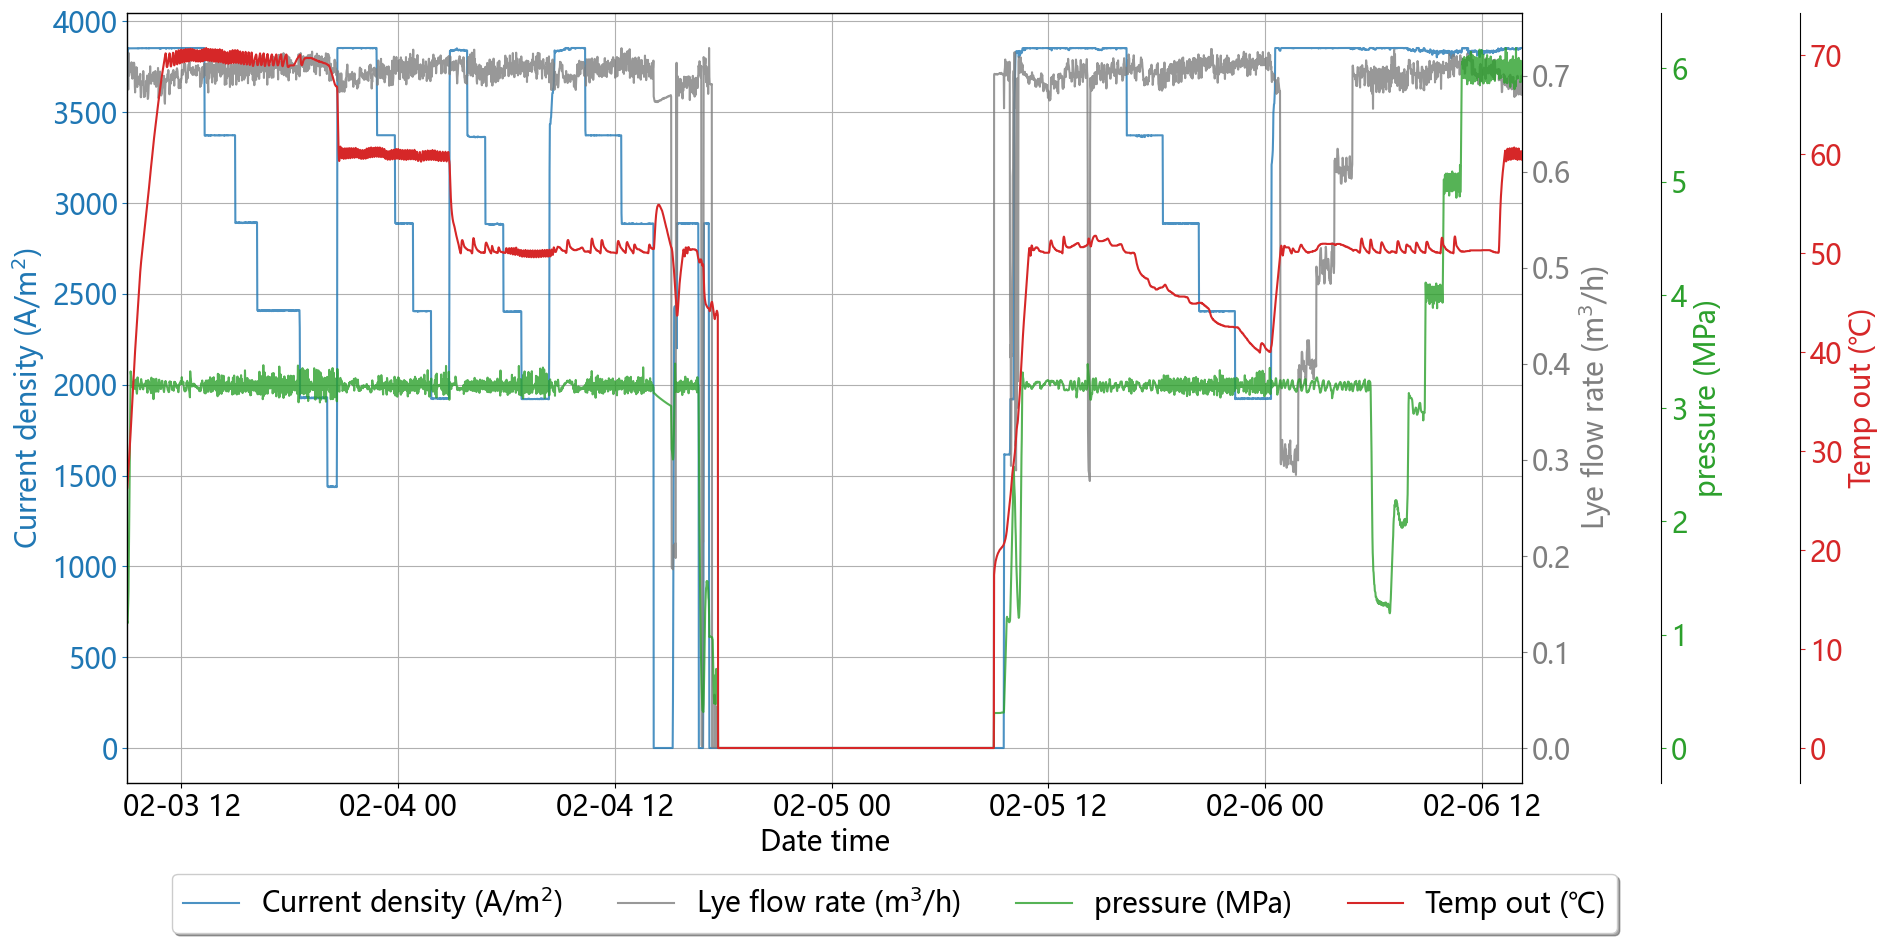

In [11]:
# 创建图表和子图
fig, ax1 = plt.subplots(figsize=(18, 10))
plt.grid(True)

# 绘制碱液流量曲线
ax1.plot(df_Hyzenis[Cols.date_time], df_Hyzenis[Cols.current_density], c = '#1f77b4', alpha = 0.8,label = 'Current density (A/m$^2$)')
ax1.set_ylabel('Current density (A/m$^2$)', color='#1f77b4')
ax1.margins(x=0)  # 仅消除x轴边距
ax1.set_xlabel('Date time')
ax1.tick_params('y', colors='#1f77b4')
# ax1.set_ylim((1800, 4800))

# 创建第二个y轴
ax2 = ax1.twinx()

# 绘制第电流曲线
ax2.plot(df_Hyzenis[Cols.date_time], df_Hyzenis[Cols.lye_flow], alpha=0.8, c = '#7f7f7f', label = 'Lye flow rate (m$^3$/h)')
ax2.set_ylabel('Lye flow rate (m$^3$/h)', color='#7f7f7f')
ax2.tick_params('y', colors='#7f7f7f')
# ax2.set_ylim(0.2, 1.0)


# 创建第三个y轴
ax3 = ax1.twinx()

# 绘制电压曲线
ax3.plot(df_Hyzenis[Cols.date_time],df_Hyzenis[Cols.pressure], c = '#2ca02c', alpha = 0.8,label = 'pressure (MPa)')
ax3.set_ylabel('pressure (MPa)', color='#2ca02c')
ax3.spines['right'].set_position(('outward', 100))
ax3.tick_params('y', colors='#2ca02c')
# ax3.set_ylim((1.7, 2.1))


# 创建第四个y轴
ax4 = ax1.twinx()

# 绘制出口温度曲线
ax4.plot(df_Hyzenis[Cols.date_time],df_Hyzenis[Cols.lye_temp], c = '#d62728', label = 'Temp out (℃)')
ax4.set_xlabel('Date time')
ax4.set_ylabel('Temp out (℃)', color='#d62728')
ax4.spines['right'].set_position(('outward', 200))
ax4.tick_params('y', colors='#d62728')
# ax4.set_ylim(30, 105)


# 添加图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, loc='upper center',
           bbox_to_anchor=(0.55, -0.1), ncol=4, frameon=True, fancybox=True, shadow=True, fontsize=20)

# 显示图表
plt.show()

### 划分不同的实验区间

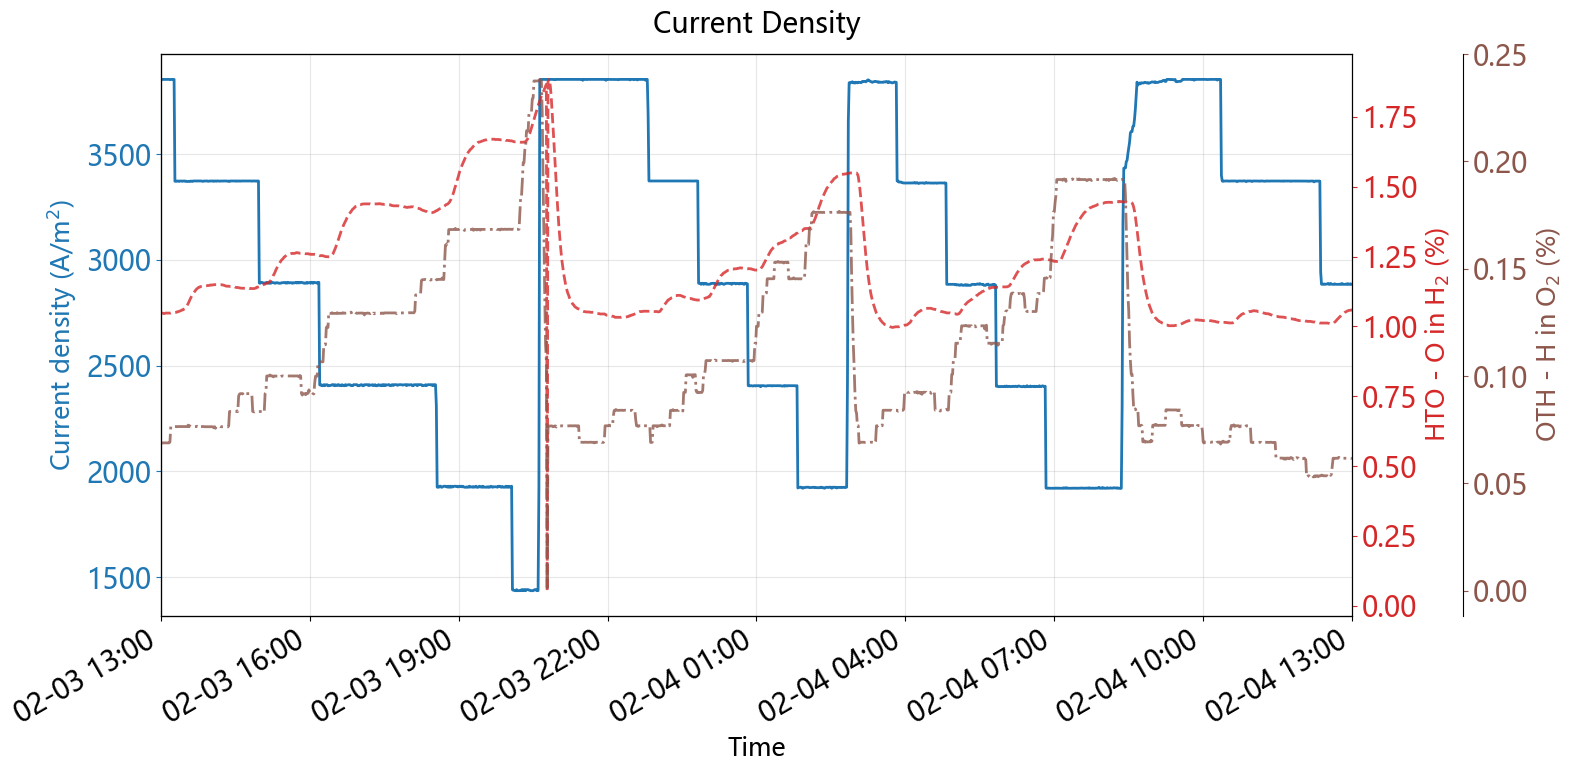

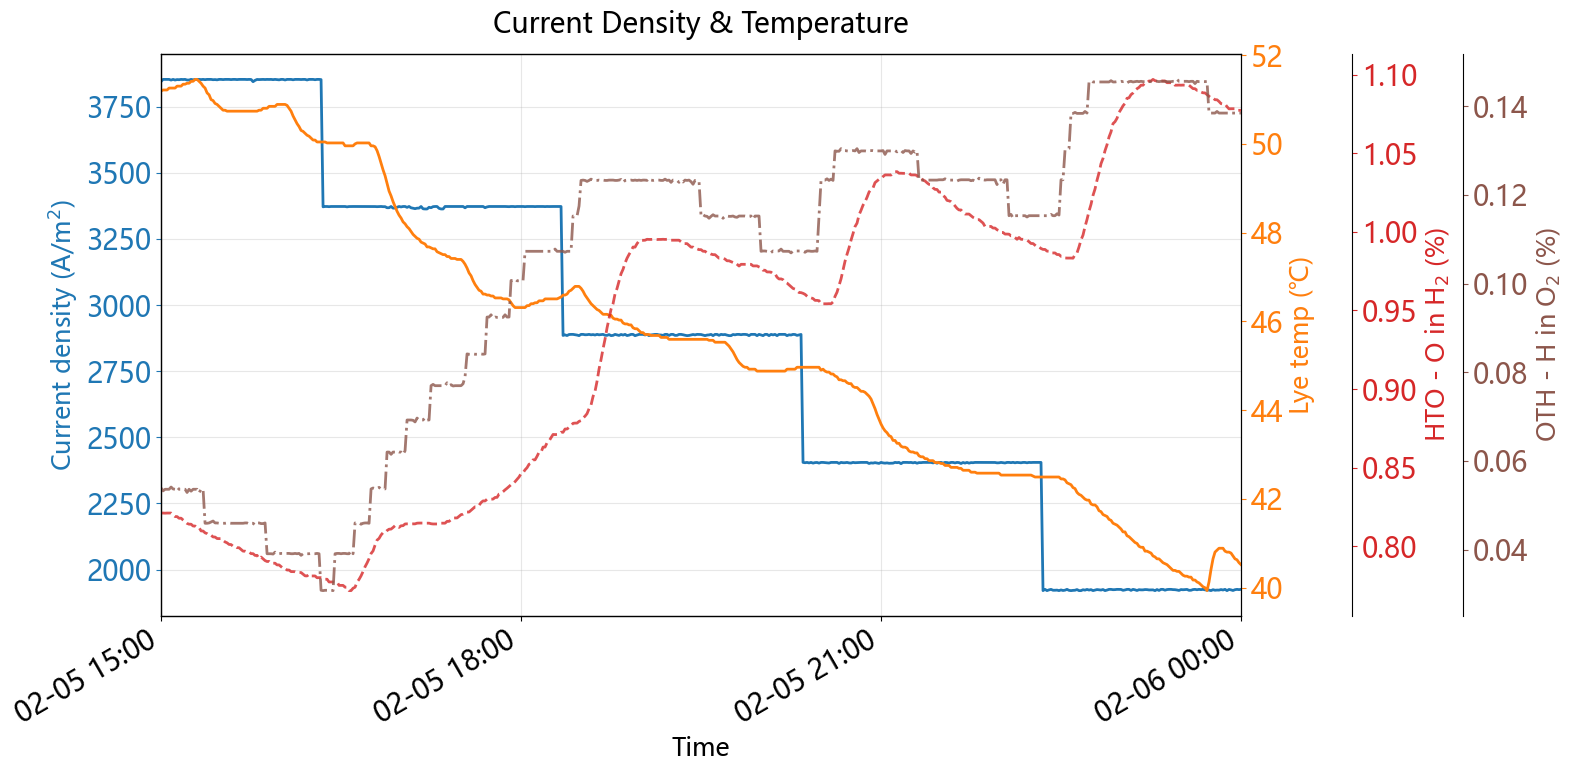

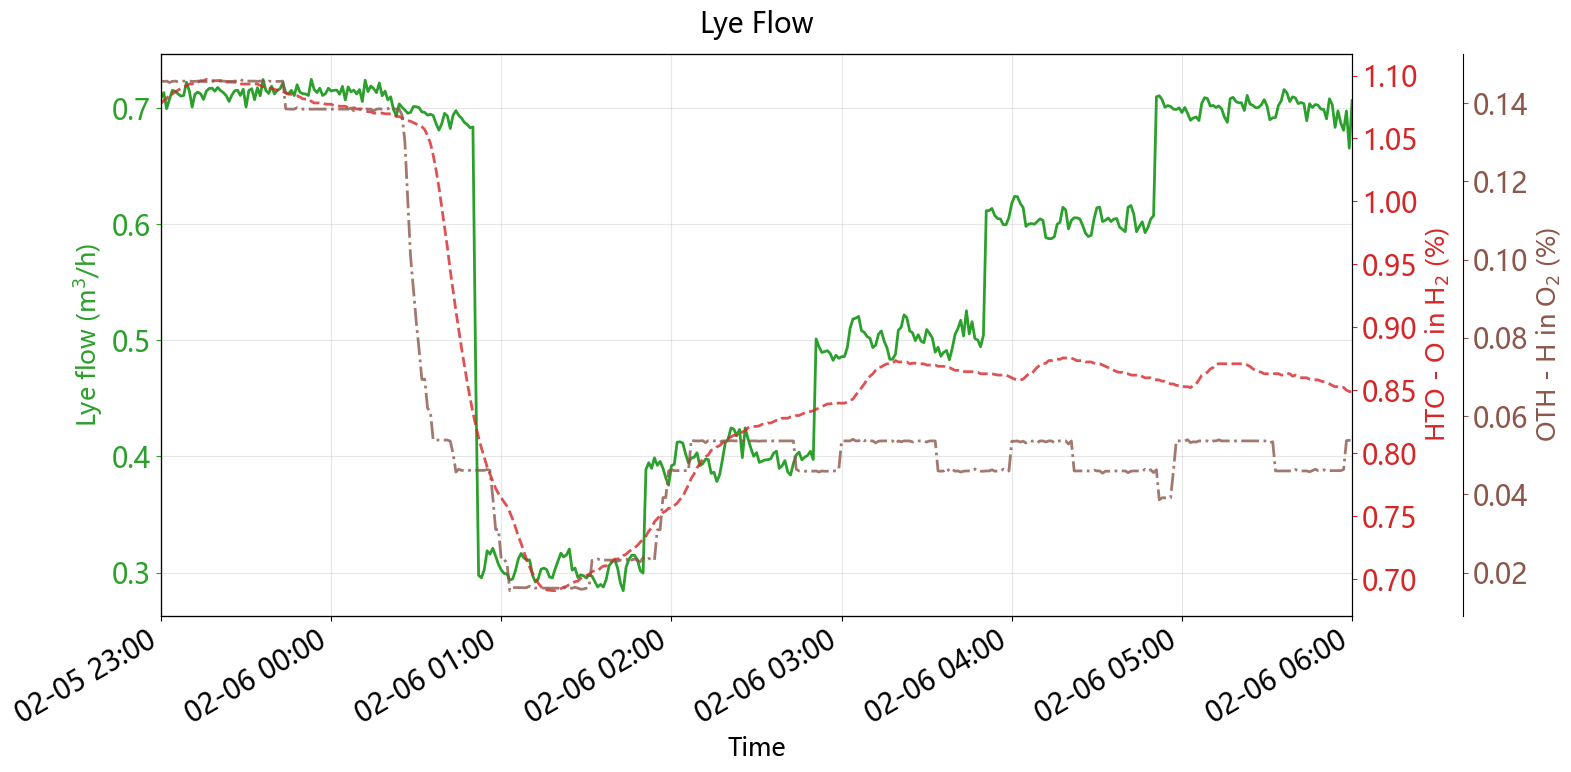

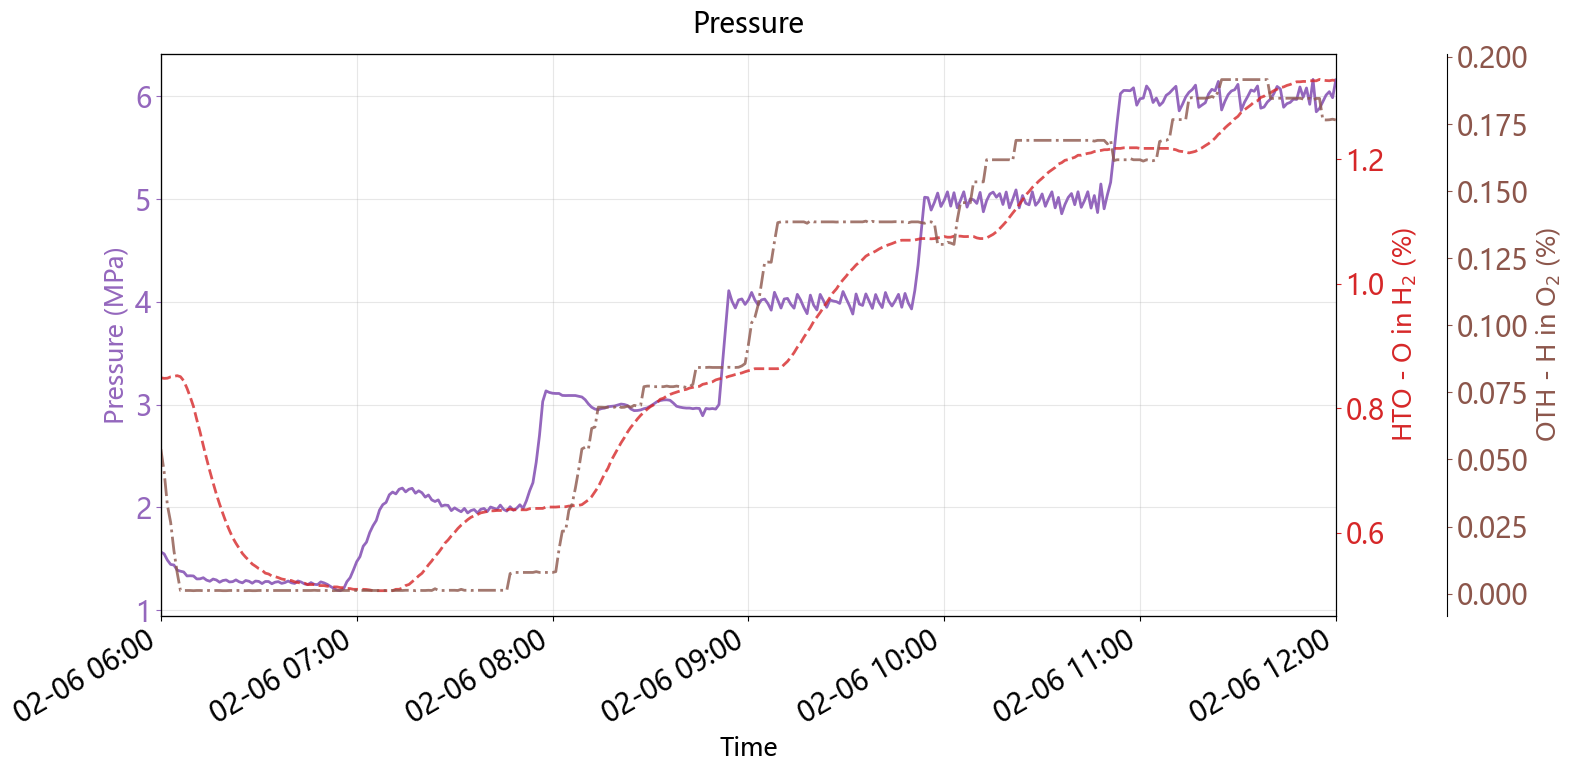

In [25]:
import matplotlib.dates as mdates

# 定义时间区间
time_range_current = ("2026-02-03 13:00:00", "2026-02-04 13:00:00")  # current单变量
time_range_current_temp = ("2026-02-05 15:00:00", "2026-02-06 00:00:00")  # current, temp双变量
time_range_lye_flow = ("2026-02-05 23:00:00", "2026-02-06 06:00:00")  # lye_flow单变量
time_range_pressure = ("2026-02-06 06:00:00", "2026-02-06 12:00:00")  # pressure单变量

# 图1：Current Density
mask = (df_Hyzenis[Cols.date_time] >= time_range_current[0]) & (df_Hyzenis[Cols.date_time] <= time_range_current[1])
df_plot = df_Hyzenis[mask]

fig, ax1 = plt.subplots(figsize=(16, 8))
ax1.grid(True, alpha=0.3)

# 主变量：电流密度
ax1.plot(df_plot[Cols.date_time], df_plot[Cols.current_density], 
        c='#1f77b4', linewidth=2, label='Current density (A/m$^2$)')
ax1.set_ylabel('Current density (A/m$^2$)', color='#1f77b4', fontsize=18)
ax1.tick_params('y', colors='#1f77b4')
ax1.set_xlabel('Time', fontsize=18)
ax1.margins(x=0)

# HTO 轴
ax2 = ax1.twinx()
ax2.plot(df_plot[Cols.date_time], df_plot[Cols.HTO], 
        c='#d62728', linewidth=2, linestyle='--', label='HTO (%)', alpha=0.8)
ax2.set_ylabel('HTO - O in H$_2$ (%)', color='#d62728', fontsize=18)
ax2.tick_params('y', colors='#d62728')

# OTH 轴
ax3 = ax1.twinx()
ax3.plot(df_plot[Cols.date_time], df_plot[Cols.OTH], 
        c='#8c564b', linewidth=2, linestyle='-.', label='OTH (%)', alpha=0.8)
ax3.set_ylabel('OTH - H in O$_2$ (%)', color='#8c564b', fontsize=18)
ax3.tick_params('y', colors='#8c564b')
ax3.spines['right'].set_position(('outward', 80))

ax1.set_title('Current Density', fontsize=20, pad=15)
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for label in ax1.get_xticklabels():
    label.set_rotation(30)
    label.set_ha('right')

plt.tight_layout()
plt.show()

# 图2：Current Density & Temperature
mask = (df_Hyzenis[Cols.date_time] >= time_range_current_temp[0]) & (df_Hyzenis[Cols.date_time] <= time_range_current_temp[1])
df_plot = df_Hyzenis[mask]

fig, ax1 = plt.subplots(figsize=(16, 8))
ax1.grid(True, alpha=0.3)

# 主变量：电流密度
ax1.plot(df_plot[Cols.date_time], df_plot[Cols.current_density], 
        c='#1f77b4', linewidth=2, label='Current density (A/m$^2$)')
ax1.set_ylabel('Current density (A/m$^2$)', color='#1f77b4', fontsize=18)
ax1.tick_params('y', colors='#1f77b4')
ax1.set_xlabel('Time', fontsize=18)
ax1.margins(x=0)

# 温度轴
ax_temp = ax1.twinx()
ax_temp.plot(df_plot[Cols.date_time], df_plot[Cols.lye_temp], 
            c='#ff7f0e', linewidth=2, label='Lye temp (℃)')
ax_temp.set_ylabel('Lye temp (℃)', color='#ff7f0e', fontsize=18)
ax_temp.tick_params('y', colors='#ff7f0e')

# HTO 轴
ax2 = ax1.twinx()
ax2.plot(df_plot[Cols.date_time], df_plot[Cols.HTO], 
        c='#d62728', linewidth=2, linestyle='--', label='HTO (%)', alpha=0.8)
ax2.set_ylabel('HTO - O in H$_2$ (%)', color='#d62728', fontsize=18)
ax2.tick_params('y', colors='#d62728')
ax2.spines['right'].set_position(('outward', 80))

# OTH 轴
ax3 = ax1.twinx()
ax3.plot(df_plot[Cols.date_time], df_plot[Cols.OTH], 
        c='#8c564b', linewidth=2, linestyle='-.', label='OTH (%)', alpha=0.8)
ax3.set_ylabel('OTH - H in O$_2$ (%)', color='#8c564b', fontsize=18)
ax3.tick_params('y', colors='#8c564b')
ax3.spines['right'].set_position(('outward', 160))

ax1.set_title('Current Density & Temperature', fontsize=20, pad=15)
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for label in ax1.get_xticklabels():
    label.set_rotation(30)
    label.set_ha('right')

plt.tight_layout()
plt.show()

# 图3：Lye Flow
mask = (df_Hyzenis[Cols.date_time] >= time_range_lye_flow[0]) & (df_Hyzenis[Cols.date_time] <= time_range_lye_flow[1])
df_plot = df_Hyzenis[mask]

fig, ax1 = plt.subplots(figsize=(16, 8))
ax1.grid(True, alpha=0.3)

# 主变量：碱液流量
ax1.plot(df_plot[Cols.date_time], df_plot[Cols.lye_flow], 
        c='#2ca02c', linewidth=2, label='Lye flow (m$^3$/h)')
ax1.set_ylabel('Lye flow (m$^3$/h)', color='#2ca02c', fontsize=18)
ax1.tick_params('y', colors='#2ca02c')
ax1.set_xlabel('Time', fontsize=18)
ax1.margins(x=0)

# HTO 轴
ax2 = ax1.twinx()
ax2.plot(df_plot[Cols.date_time], df_plot[Cols.HTO], 
        c='#d62728', linewidth=2, linestyle='--', label='HTO (%)', alpha=0.8)
ax2.set_ylabel('HTO - O in H$_2$ (%)', color='#d62728', fontsize=18)
ax2.tick_params('y', colors='#d62728')

# OTH 轴
ax3 = ax1.twinx()
ax3.plot(df_plot[Cols.date_time], df_plot[Cols.OTH], 
        c='#8c564b', linewidth=2, linestyle='-.', label='OTH (%)', alpha=0.8)
ax3.set_ylabel('OTH - H in O$_2$ (%)', color='#8c564b', fontsize=18)
ax3.tick_params('y', colors='#8c564b')
ax3.spines['right'].set_position(('outward', 80))

ax1.set_title('Lye Flow', fontsize=20, pad=15)
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for label in ax1.get_xticklabels():
    label.set_rotation(30)
    label.set_ha('right')

plt.tight_layout()
plt.show()

# 图4：Pressure
mask = (df_Hyzenis[Cols.date_time] >= time_range_pressure[0]) & (df_Hyzenis[Cols.date_time] <= time_range_pressure[1])
df_plot = df_Hyzenis[mask]

fig, ax1 = plt.subplots(figsize=(16, 8))
ax1.grid(True, alpha=0.3)

# 主变量：压力
ax1.plot(df_plot[Cols.date_time], df_plot[Cols.pressure], 
        c='#9467bd', linewidth=2, label='Pressure (MPa)')
ax1.set_ylabel('Pressure (MPa)', color='#9467bd', fontsize=18)
ax1.tick_params('y', colors='#9467bd')
ax1.set_xlabel('Time', fontsize=18)
ax1.margins(x=0)

# HTO 轴
ax2 = ax1.twinx()
ax2.plot(df_plot[Cols.date_time], df_plot[Cols.HTO], 
        c='#d62728', linewidth=2, linestyle='--', label='HTO (%)', alpha=0.8)
ax2.set_ylabel('HTO - O in H$_2$ (%)', color='#d62728', fontsize=18)
ax2.tick_params('y', colors='#d62728')

# OTH 轴
ax3 = ax1.twinx()
ax3.plot(df_plot[Cols.date_time], df_plot[Cols.OTH], 
        c='#8c564b', linewidth=2, linestyle='-.', label='OTH (%)', alpha=0.8)
ax3.set_ylabel('OTH - H in O$_2$ (%)', color='#8c564b', fontsize=18)
ax3.tick_params('y', colors='#8c564b')
ax3.spines['right'].set_position(('outward', 80))

ax1.set_title('Pressure', fontsize=20, pad=15)
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for label in ax1.get_xticklabels():
    label.set_rotation(30)
    label.set_ha('right')

plt.tight_layout()
plt.show()